![alt text](http://media5.datahacker.rs/2018/06/logo-crno.png)

[datahacker.rs](http://datahacker.rs)

# 使用 TensorFlow 2 實作 YOLOv3（詳細中文註解版）

本筆記本示範如何建立 YOLOv3、載入 Darknet 官方預訓練權重，並對上傳圖片進行物件偵測。中文註解不改變老師原始程式邏輯。

## 1. 準備 Google Colab 執行環境

### TensorFlow 版本

本教材需要 TensorFlow 2。舊版 Colab 曾使用 `%tensorflow_version 2.x` 切換版本；目前 Colab 通常已預設新版 TensorFlow，因此該指令可以保持註解。

In [32]:
# 【Colab 版本設定】
# 舊版 Colab 可用這個 magic 指令切換到 TensorFlow 2.x。
# 現行 Colab 已預設 TensorFlow 2，因此這行通常不再支援，也不需要執行。

# %tensorflow_version 2.x

### 下載 YOLOv3 預訓練權重

In [33]:
# 【下載預訓練權重】
# wget 是 Linux 下載指令；驚嘆號表示由 Colab 的系統 shell 執行，而非 Python。
# 下載的是 Darknet 官方訓練好的 YOLOv3 權重，檔案約 236 MB。
# 若原網址失效，可改用可信任的鏡像或自行上傳 yolov3.weights。

!wget https://pjreddie.com/media/files/yolov3.weights

--2026-09-14 13:23:57--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3033::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-09-14 13:23:57--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3033::ac43:b9c7, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights.6’

yolov3.weights.6    100%[===================>] 236.52M  95.6MB/s    in 2.5s    

2026-09-14 13:24:00 (95.6 MB/s) - ‘yolov3.weights.6’ saved [248007048/248007048]



### 建立存放轉換後權重的資料夾

In [34]:
# 【清除舊權重資料夾】
# -r 代表遞迴刪除，-f 代表不詢問。重新執行筆記本時可避免舊檔干擾。
# 注意：此命令會刪除 checkpoints 內所有內容。

!rm -rf checkpoints

In [35]:
# 【建立權重資料夾】
# 建立 checkpoints，稍後用來存放轉換後、可由 Keras 讀取的權重。

!mkdir checkpoints

### 匯入所需套件

In [36]:
# 【匯入套件】
# cv2：讀寫圖片、畫框與文字；NumPy：陣列及 Darknet 二進位權重處理。
# TensorFlow/Keras：建立模型、張量運算、損失函數與推論。
# cv2_imshow：Colab 專用顯示函式，取代桌面環境的 cv2.imshow。
# repeat：建立固定次數的殘差區塊；l2：卷積核正則化，降低過擬合。

import cv2
import numpy as np
import tensorflow as tf

from absl import logging
from itertools import repeat
from google.colab.patches import cv2_imshow

from tensorflow.keras import Model
from tensorflow.keras.layers import Add, Concatenate, Lambda
from tensorflow.keras.layers import Conv2D, Input, LeakyReLU
from tensorflow.keras.layers import MaxPool2D, UpSampling2D, ZeroPadding2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.losses import sparse_categorical_crossentropy

In [37]:
# 【確認 TensorFlow 版本】
# 印出目前版本，若教材年代較舊而發生 API 錯誤，這是第一個要檢查的資訊。

print(tf.__version__)

2.20.0


### 設定推論門檻、檔案路徑、輸入尺寸及類別數

In [38]:
# 【全域設定】
# IoU 門檻：重疊過高的候選框在 NMS 中會被視為重複。
# 分數門檻：只保留物件信心分數達門檻的框；調低可增加框數但也增加誤判。
# size=416 是 YOLOv3 常用輸入尺寸；COCO 預訓練模型共有 80 類。

yolo_iou_threshold   = 0.6 # iou threshold
yolo_score_threshold = 0.6 # score threshold

weightsyolov3 = 'yolov3.weights' # path to weights file
weights= 'checkpoints/yolov3.tf' # path to checkpoints file
size= 416             #resize images to\
checkpoints = 'checkpoints/yolov3.tf'
num_classes = 80      # number of classes in the model

### 定義 YOLOv3 中需要載入 Darknet 權重的子模型

In [39]:
# 【需要載入權重的子模型名稱】
# 名稱及順序必須和模型建立時完全一致，才能把 Darknet 權重逐層放進 Keras。
# 包含 Darknet-53 骨幹、三個尺度的特徵融合層與三個輸出頭。

YOLO_V3_LAYERS = [
  'yolo_darknet',
  'yolo_conv_0',
  'yolo_output_0',
  'yolo_conv_1',
  'yolo_output_1',
  'yolo_conv_2',
  'yolo_output_2',
]

## 2. 讀取 Darknet 官方權重

Darknet 與 TensorFlow/Keras 的卷積核排列及 Batch Normalization 權重順序不同，因此需要逐層讀取、重排再寫入模型。

In [40]:
# 【Darknet → Keras 權重轉換】
# 1. 讀取 Darknet 檔頭；2. 依模型順序找 Conv2D；3. 讀取 BN 或 bias；
# 4. 將 Darknet 卷積格式 (out,in,h,w) 轉為 Keras 格式 (h,w,in,out)；5. 寫入各層。
# BatchNorm 在 Darknet 的順序為 beta,gamma,mean,var，Keras 則為 gamma,beta,mean,var，故需重排。
# in_dim 使用 layer.input.shape[-1]；新版 Keras 若尚未建立輸入張量可能報 input 屬性錯誤，
# 本教材先以實際輸入建立完整 YoloV3 模型後才呼叫此函式。

def load_darknet_weights(model, weights_file):
  wf = open(weights_file, 'rb')
  major, minor, revision, seen, _ = np.fromfile(wf, dtype=np.int32, count=5)
  layers = YOLO_V3_LAYERS

  for layer_name in layers:
    sub_model = model.get_layer(layer_name)
    for i, layer in enumerate(sub_model.layers):
      if not layer.name.startswith('conv2d'):
        continue
      batch_norm = None
      if i + 1 < len(sub_model.layers) and \
            sub_model.layers[i + 1].name.startswith('batch_norm'):
        batch_norm = sub_model.layers[i + 1]

      logging.info("{}/{} {}".format(
        sub_model.name, layer.name, 'bn' if batch_norm else 'bias'))

      filters = layer.filters
      size = layer.kernel_size[0]
      in_dim = layer.input.shape[-1]

      if batch_norm is None:
        conv_bias = np.fromfile(wf, dtype=np.float32, count=filters)
      else:
        bn_weights = np.fromfile(
          wf, dtype=np.float32, count=4 * filters)

        bn_weights = bn_weights.reshape((4, filters))[[1, 0, 2, 3]]

      conv_shape = (filters, in_dim, size, size)
      conv_weights = np.fromfile(
        wf, dtype=np.float32, count=np.prod(conv_shape))

      conv_weights = conv_weights.reshape(
        conv_shape).transpose([2, 3, 1, 0])

      if batch_norm is None:
        layer.set_weights([conv_weights, conv_bias])
      else:
        layer.set_weights([conv_weights])
        batch_norm.set_weights(bn_weights)

  assert len(wf.read()) == 0, 'failed to read all data'
  wf.close()

## 3. IoU（Intersection over Union，交並比）

IoU 衡量兩個邊界框重疊程度，常用於評估定位準確度及 NMS 判定。

In [41]:
# 【IoU（交並比）】
# interval_overlap 計算一維區間重疊長度；intersectionOverUnion 再組合成二維面積。
# IoU = 交集面積 / 聯集面積，範圍 0～1，越接近 1 表示兩個框越重合。
# 此函式期待 box1、box2 具有 xmin、xmax、ymin、ymax 屬性。

def interval_overlap(interval_1, interval_2):
  x1, x2 = interval_1
  x3, x4 = interval_2
  if x3 < x1:
    return 0 if x4 < x1 else (min(x2,x4) - x1)
  else:
    return 0 if x2 < x3 else (min(x2,x4) - x3)

def intersectionOverUnion(box1, box2):
  intersect_w = interval_overlap([box1.xmin, box1.xmax], [box2.xmin, box2.xmax])
  intersect_h = interval_overlap([box1.ymin, box1.ymax], [box2.ymin, box2.ymax])
  intersect_area = intersect_w * intersect_h

  w1, h1 = box1.xmax-box1.xmin, box1.ymax-box1.ymin
  w2, h2 = box2.xmax-box2.xmin, box2.ymax-box2.ymin

  union_area = w1*h1 + w2*h2 - intersect_area
  return float(intersect_area) / union_area

### 繪製預測框、類別名稱與信心分數

In [42]:
# 【把偵測結果畫回圖片】
# outputs 含 boxes、scores、classes、nums；第一維是 batch，所以用 [0] 取第一張圖。
# 模型輸出的框座標已正規化到 0～1，乘上 (寬,高) 後轉回像素座標。
# OpenCV 顏色採 BGR：框 (255,0,0) 是藍色，文字 (0,0,255) 是紅色。

def draw_outputs(img, outputs, class_names):
  boxes, score, classes, nums = outputs
  boxes, score, classes, nums = boxes[0], score[0], classes[0], nums[0]
  wh = np.flip(img.shape[0:2])
  for i in range(nums):
    x1y1 = tuple((np.array(boxes[i][0:2]) * wh).astype(np.int32))
    x2y2 = tuple((np.array(boxes[i][2:4]) * wh).astype(np.int32))
    img = cv2.rectangle(img, x1y1, x2y2, (255, 0, 0), 2)
    img = cv2.putText(img, '{} {:.4f}'.format(
      class_names[int(classes[i])], score[i]),
      x1y1, cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0, 0, 255), 2)
  return img

### 自訂 Batch Normalization 行為

In [43]:
# 【自訂 Batch Normalization】
# 只有 training=True 且此層 trainable=True 時，才更新批次統計量；否則使用移動平均值。
# 這能配合凍結層（transfer learning）時的行為，避免 BN 統計值被意外更新。

class BatchNormalization(tf.keras.layers.BatchNormalization):
  def call(self, x, training=False):
    if training is None: training = tf.constant(False)
    training = tf.logical_and(training, self.trainable)
    return super().call(x, training)

### 定義九組 Anchor boxes 與三個尺度的 mask

In [44]:
# 【Anchor boxes】
# 九組寬高來自 COCO 資料集聚類結果，除以 416 後轉為相對於輸入影像的比例。
# 三組 mask 分別給 13×13、26×26、52×52 特徵圖：大、中、小 anchor 各三個。

yolo_anchors = np.array([(10, 13), (16, 30), (33, 23), (30, 61), (62, 45),
                        (59, 119), (116, 90), (156, 198), (373, 326)], np.float32) / 416
yolo_anchor_masks = np.array([[6, 7, 8], [3, 4, 5], [0, 1, 2]])



---



## 4. Darknet-53 與 YOLOv3 模型架構

<center><img src="http://media5.datahacker.rs/2019/10/yolo-arch.jpg"></center>

### 建立自訂網路層與完整模型

In [45]:
# 【Darknet-53 骨幹網路】
# DarknetConv：卷積 +（可選）BN + LeakyReLU；stride=2 時先做非對稱補零再降採樣。
# DarknetResidual：1×1 降通道後接 3×3 卷積，再與原輸入相加形成殘差連接。
# DarknetBlock：一次 stride=2 降採樣，再重複指定數量的殘差單元。
# Darknet 回傳三個尺度的特徵圖，供後續特徵金字塔進行多尺度偵測。

def DarknetConv(x, filters, size, strides=1, batch_norm=True):
  if strides == 1:
    padding = 'same'
  else:
    x = ZeroPadding2D(((1, 0), (1, 0)))(x)  # top left half-padding
    padding = 'valid'
  x = Conv2D(filters=filters, kernel_size=size,
          strides=strides, padding=padding,
          use_bias=not batch_norm, kernel_regularizer=l2(0.0005))(x)
  if batch_norm:
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=0.1)(x)
  return x

def DarknetResidual(x, filters):
  previous  = x
  x = DarknetConv(x, filters // 2, 1)
  x = DarknetConv(x, filters, 3)
  x = Add()([previous , x])
  return x


def DarknetBlock(x, filters, blocks):
  x = DarknetConv(x, filters, 3, strides=2)
  for _ in repeat(None, blocks):
    x = DarknetResidual(x, filters)
  return x


def Darknet(name=None):
  x = inputs = Input([None, None, 3])
  x = DarknetConv(x, 32, 3)
  x = DarknetBlock(x, 64, 1)
  x = DarknetBlock(x, 128, 2)
  x = x_36 = DarknetBlock(x, 256, 8)
  x = x_61 = DarknetBlock(x, 512, 8)
  x = DarknetBlock(x, 1024, 4)
  return tf.keras.Model(inputs, (x_36, x_61, x), name=name)

In [46]:
# 【YOLO 特徵融合層】
# 若輸入是 tuple，代表要把深層特徵先 1×1 卷積、上採樣 2 倍，再和淺層 skip feature 串接。
# Concatenate 沿通道維合併，使模型同時保留高階語意與較精細的空間資訊。
# 後面的五層交替 1×1/3×3 卷積負責進一步提煉特徵。

def YoloConv(filters, name=None):
  def yolo_conv(x_in):
    if isinstance(x_in, tuple):
      inputs = Input(x_in[0].shape[1:]), Input(x_in[1].shape[1:])
      x, x_skip = inputs

      x = DarknetConv(x, filters, 1)
      x = UpSampling2D(2)(x)
      x = Concatenate()([x, x_skip])
    else:
      x = inputs = Input(x_in.shape[1:])

    x = DarknetConv(x, filters, 1)
    x = DarknetConv(x, filters * 2, 3)
    x = DarknetConv(x, filters, 1)
    x = DarknetConv(x, filters * 2, 3)
    x = DarknetConv(x, filters, 1)
    return Model(inputs, x, name=name)(x_in)
  return yolo_conv

In [47]:
# 【YOLO 輸出頭】
# 每個 grid、每個 anchor 都預測 classes+5 個值：x、y、w、h、objectness、各類別分數。
# 因此最後通道數為 anchors × (classes+5)，再 reshape 成五維張量。
# 最後一層不使用 BN，並保留線性輸出，稍後才套 sigmoid/exp 解碼。

def YoloOutput(filters, anchors, classes, name=None):
  def yolo_output(x_in):
    x = inputs = Input(x_in.shape[1:])
    x = DarknetConv(x, filters * 2, 3)
    x = DarknetConv(x, anchors * (classes + 5), 1, batch_norm=False)
    x = Lambda(lambda x: tf.reshape(x, (-1, tf.shape(x)[1], tf.shape(x)[2],
                                        anchors, classes + 5)))(x)
    return tf.keras.Model(inputs, x, name=name)(x_in)
  return yolo_output

In [48]:
# 【解碼模型原始預測】
# tf.split 將最後一維拆成中心座標、寬高、物件分數與類別機率。
# sigmoid 把中心偏移/機率限制到 0～1；exp(width,height)×anchor 還原框尺寸。
# meshgrid 產生每個網格座標，再把相對網格位置換成整張圖的正規化座標。
# bbox 格式為 (x1,y1,x2,y2)；pred_box 保留 loss 所需的原始 xywh 表示。

def yolo_boxes(pred, anchors, classes):
  grid_size = tf.shape(pred)[1]
  box_xy, box_wh, score, class_probs = tf.split(pred, (2, 2, 1, classes), axis=-1)

  box_xy = tf.sigmoid(box_xy)
  score = tf.sigmoid(score)
  class_probs = tf.sigmoid(class_probs)
  pred_box = tf.concat((box_xy, box_wh), axis=-1)

  grid = tf.meshgrid(tf.range(grid_size), tf.range(grid_size))
  grid = tf.expand_dims(tf.stack(grid, axis=-1), axis=2)

  box_xy = (box_xy + tf.cast(grid, tf.float32)) /  tf.cast(grid_size, tf.float32)
  box_wh = tf.exp(box_wh) * anchors

  box_x1y1 = box_xy - box_wh / 2
  box_x2y2 = box_xy + box_wh / 2
  bbox = tf.concat([box_x1y1, box_x2y2], axis=-1)

  return bbox, score, class_probs, pred_box

### Non-Maximum Suppression（非極大值抑制）

同一物件常產生多個重疊候選框；NMS 保留高分框並移除重複框。

In [49]:
# 【非極大值抑制 NMS】
# 先攤平並串接三個尺度的候選框，再以 objectness×class probability 得到類別分數。
# combined_non_max_suppression 會逐類別移除與高分框高度重疊的低分框。
# 最多每類保留 100 框、整張圖最多 100 框，門檻使用前面設定的全域參數。

def nonMaximumSuppression(outputs, anchors, masks, classes):
  boxes, conf, out_type = [], [], []

  for output in outputs:
    boxes.append(tf.reshape(output[0], (tf.shape(output[0])[0], -1, tf.shape(output[0])[-1])))
    conf.append(tf.reshape(output[1], (tf.shape(output[1])[0], -1, tf.shape(output[1])[-1])))
    out_type.append(tf.reshape(output[2], (tf.shape(output[2])[0], -1, tf.shape(output[2])[-1])))

  bbox = tf.concat(boxes, axis=1)
  confidence = tf.concat(conf, axis=1)
  class_probs = tf.concat(out_type, axis=1)

  scores = confidence * class_probs

  boxes, scores, classes, valid_detections = tf.image.combined_non_max_suppression(
    boxes=tf.reshape(bbox, (tf.shape(bbox)[0], -1, 1, 4)),
    scores=tf.reshape(
        scores, (tf.shape(scores)[0], -1, tf.shape(scores)[-1])),
    max_output_size_per_class=100,
    max_total_size=100,
    iou_threshold=yolo_iou_threshold,
    score_threshold=yolo_score_threshold
  )

  return boxes, scores, classes, valid_detections

In [50]:
# 【組裝完整 YOLOv3】
# Darknet-53 產生三層特徵；三個偵測頭依序處理 13×13、26×26、52×52 尺度。
# training=True 時回傳三個未解碼輸出供 loss 計算；推論時則解碼並執行 NMS。
# 大網格較適合小物件，小網格的感受野較大，較適合大型物件。

def YoloV3(size=None, channels=3, anchors=yolo_anchors,
          masks=yolo_anchor_masks, classes=80, training=False):
  x = inputs = Input([size, size, channels])

  x_36, x_61, x = Darknet(name='yolo_darknet')(x)

  x = YoloConv(512, name='yolo_conv_0')(x)
  output_0 = YoloOutput(512, len(masks[0]), classes, name='yolo_output_0')(x)

  x = YoloConv(256, name='yolo_conv_1')((x, x_61))
  output_1 = YoloOutput(256, len(masks[1]), classes, name='yolo_output_1')(x)

  x = YoloConv(128, name='yolo_conv_2')((x, x_36))
  output_2 = YoloOutput(128, len(masks[2]), classes, name='yolo_output_2')(x)

  if training:
    return Model(inputs, (output_0, output_1, output_2), name='yolov3')

  boxes_0 = Lambda(lambda x: yolo_boxes(x, anchors[masks[0]], classes),
                  name='yolo_boxes_0')(output_0)
  boxes_1 = Lambda(lambda x: yolo_boxes(x, anchors[masks[1]], classes),
                  name='yolo_boxes_1')(output_1)
  boxes_2 = Lambda(lambda x: yolo_boxes(x, anchors[masks[2]], classes),
                  name='yolo_boxes_2')(output_2)

  outputs = Lambda(lambda x: nonMaximumSuppression(x, anchors, masks, classes),
                  name='nonMaximumSuppression')((boxes_0[:3], boxes_1[:3], boxes_2[:3]))

  return Model(inputs, outputs, name='yolov3')

In [51]:
# 【YOLOv3 損失函數】
# 損失由中心座標 xy、框寬高 wh、物件存在與否 objectness、類別四部分組成。
# 小框以 2−框面積提高權重，避免大框主導定位損失。
# ignore_mask：若無物件位置的預測框與真實框 IoU 已很高，不將它當成負樣本懲罰。
# 注意：本儲存格呼叫 broadcast_iou，但原教材未定義它；只有進行訓練才會用到並可能報錯，
# 單純載入預訓練權重做圖片推論不會呼叫 YoloLoss。

def YoloLoss(anchors, classes=80, ignore_thresh=0.5):
    def yolo_loss(y_true, y_pred):
        # 1. transform all pred outputs
        # y_pred: (batch_size, grid, grid, anchors, (x, y, w, h, obj, ...cls))
        pred_box, pred_obj, pred_class, pred_xywh = yolo_boxes(
            y_pred, anchors, classes)
        pred_xy = pred_xywh[..., 0:2]
        pred_wh = pred_xywh[..., 2:4]

        # 2. transform all true outputs
        # y_true: (batch_size, grid, grid, anchors, (x1, y1, x2, y2, obj, cls))
        true_box, true_obj, true_class_idx = tf.split(
            y_true, (4, 1, 1), axis=-1)
        true_xy = (true_box[..., 0:2] + true_box[..., 2:4]) / 2
        true_wh = true_box[..., 2:4] - true_box[..., 0:2]

        # give higher weights to small boxes
        box_loss_scale = 2 - true_wh[..., 0] * true_wh[..., 1]

        # 3. inverting the pred box equations
        grid_size = tf.shape(y_true)[1]
        grid = tf.meshgrid(tf.range(grid_size), tf.range(grid_size))
        grid = tf.expand_dims(tf.stack(grid, axis=-1), axis=2)
        true_xy = true_xy * tf.cast(grid_size, tf.float32) - \
            tf.cast(grid, tf.float32)
        true_wh = tf.math.log(true_wh / anchors)
        true_wh = tf.where(tf.math.is_inf(true_wh),
                           tf.zeros_like(true_wh), true_wh)

        # 4. calculate all masks
        obj_mask = tf.squeeze(true_obj, -1)
        # ignore false positive when iou is over threshold
        true_box_flat = tf.boolean_mask(true_box, tf.cast(obj_mask, tf.bool))
        best_iou = tf.reduce_max(broadcast_iou(
            pred_box, true_box_flat), axis=-1)
        ignore_mask = tf.cast(best_iou < ignore_thresh, tf.float32)

        # 5. calculate all losses
        xy_loss = obj_mask * box_loss_scale * \
            tf.reduce_sum(tf.square(true_xy - pred_xy), axis=-1)
        wh_loss = obj_mask * box_loss_scale * \
            tf.reduce_sum(tf.square(true_wh - pred_wh), axis=-1)
        obj_loss = binary_crossentropy(true_obj, pred_obj)
        obj_loss = obj_mask * obj_loss + \
            (1 - obj_mask) * ignore_mask * obj_loss
        # TODO: use binary_crossentropy instead
        class_loss = obj_mask * sparse_categorical_crossentropy(
            true_class_idx, pred_class)

        # 6. sum over (batch, gridx, gridy, anchors) => (batch, 1)
        xy_loss = tf.reduce_sum(xy_loss, axis=(1, 2, 3))
        wh_loss = tf.reduce_sum(wh_loss, axis=(1, 2, 3))
        obj_loss = tf.reduce_sum(obj_loss, axis=(1, 2, 3))
        class_loss = tf.reduce_sum(class_loss, axis=(1, 2, 3))

        return xy_loss + wh_loss + obj_loss + class_loss
    return yolo_loss

## 5. 訓練標註轉換與圖片前處理

YOLOv3 的三個輸出尺度通常為 13×13、26×26、52×52；每個尺度各負責三組 anchor。

In [52]:
# 【標註轉換與圖片前處理】
# transform_targets 先計算每個真實框最適合的 anchor，再分派到三種網格尺度。
# transform_targets_for_output 把每個框寫入 [batch,grid_y,grid_x,anchor,6] 張量；
# 最後 6 個值是 x1、y1、x2、y2、objectness、class_id。
# preprocess_image 將圖片 resize 為模型尺寸並除以 255，使像素落在 0～1。

@tf.function
def transform_targets_for_output(y_true, grid_size, anchor_idxs, classes):

  N = tf.shape(y_true)[0]

  y_true_out = tf.zeros(
      (N, grid_size, grid_size, tf.shape(anchor_idxs)[0], 6))

  anchor_idxs = tf.cast(anchor_idxs, tf.int32)

  indexes = tf.TensorArray(tf.int32, 1, dynamic_size=True)
  updates = tf.TensorArray(tf.float32, 1, dynamic_size=True)
  idx = 0
  for i in tf.range(N):
    for j in tf.range(tf.shape(y_true)[1]):
      if tf.equal(y_true[i][j][2], 0):
        continue
      anchor_eq = tf.equal(
        anchor_idxs, tf.cast(y_true[i][j][5], tf.int32))

      if tf.reduce_any(anchor_eq):
        box = y_true[i][j][0:4]
        box_xy = (y_true[i][j][0:2] + y_true[i][j][2:4]) / 2

        anchor_idx = tf.cast(tf.where(anchor_eq), tf.int32)
        grid_xy = tf.cast(box_xy // (1/grid_size), tf.int32)

        indexes = indexes.write(
            idx, [i, grid_xy[1], grid_xy[0], anchor_idx[0][0]])
        updates = updates.write(
          idx, [box[0], box[1], box[2], box[3], 1, y_true[i][j][4]])
        idx += 1

  return tf.tensor_scatter_nd_update(
    y_true_out, indexes.stack(), updates.stack())


def transform_targets(y_train, anchors, anchor_masks, classes):
  outputs = []
  grid_size = 13

  anchors = tf.cast(anchors, tf.float32)
  anchor_area = anchors[..., 0] * anchors[..., 1]
  box_wh = y_train[..., 2:4] - y_train[..., 0:2]
  box_wh = tf.tile(tf.expand_dims(box_wh, -2),
                    (1, 1, tf.shape(anchors)[0], 1))
  box_area = box_wh[..., 0] * box_wh[..., 1]
  intersection = tf.minimum(box_wh[..., 0], anchors[..., 0]) * \
    tf.minimum(box_wh[..., 1], anchors[..., 1])
  iou = intersection / (box_area + anchor_area - intersection)
  anchor_idx = tf.cast(tf.argmax(iou, axis=-1), tf.float32)
  anchor_idx = tf.expand_dims(anchor_idx, axis=-1)

  y_train = tf.concat([y_train, anchor_idx], axis=-1)

  for anchor_idxs in anchor_masks:
    outputs.append(transform_targets_for_output(
      y_train, grid_size, anchor_idxs, classes))
    grid_size *= 2

  return tuple(outputs) # [x, y, w, h, obj, class]


def preprocess_image(x_train, size):
  return (tf.image.resize(x_train, (size, size))) / 255

## 6. 載入預訓練模型並測試圖片

建立 80 類 COCO 模型、載入權重，再從電腦上傳圖片執行偵測。

In [53]:
# 【建立模型、載入 Darknet 權重、準備 COCO 類別】
# 先建立推論模型，讓各層輸入輸出形狀確定，再讀入 yolov3.weights。
# 轉換後以 .weights.h5 儲存，符合新版 Keras save_weights 的副檔名規則。
# class_names 的索引順序必須與 COCO 訓練時完全一致，才能顯示正確物件名稱。
# 原教材在此重複定義 load_darknet_weights；不影響本次已完成的載入，但後續會覆蓋同名函式。

yolo = YoloV3(size=size, classes=num_classes)

load_darknet_weights(yolo, weightsyolov3)

yolo.save_weights('checkpoints/yolov3.weights.h5') # Fix: Changed filepath extension

class_names =  ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck",
  "boat", "traffic light", "fire hydrant", "stop sign", "parking meter", "bench",
  "bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe",
  "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard",
  "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard",
  "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl",
  "banana","apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut",
  "cake","chair", "sofa", "pottedplant", "bed", "diningtable", "toilet", "tvmonitor", "laptop",
  "mouse","remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
  "refrigerator","book", "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"]

def load_darknet_weights(model, weights_file):
  wf = open(weights_file, 'rb')
  major, minor, revision, seen, _ = np.fromfile(wf, dtype=np.int32, count=5)
  layers = YOLO_V3_LAYERS

  for layer_name in layers:
    sub_model = model.get_layer(layer_name)
    for i, layer in enumerate(sub_model.layers):
      if not layer.name.startswith('conv2d'):
        continue
      batch_norm = None
      if i + 1 < len(sub_model.layers) and \
            sub_model.layers[i + 1].name.startswith('batch_norm'):
        batch_norm = sub_model.layers[i + 1]

      logging.info("{}/{} {}".format(
        sub_model.name, layer.name, 'bn' if batch_norm else 'bias'))

      filters = layer.filters
      size = layer.kernel_size[0]
      in_dim = layer.input.shape[-1]

      if batch_norm is None:
        conv_bias = np.fromfile(wf, dtype=np.float32, count=filters)
      else:
        bn_weights = np.fromfile(
          wf, dtype=np.float32, count=4 * filters)

        bn_weights = bn_weights.reshape((4, filters))[[1, 0, 2, 3]]

      conv_shape = (filters, in_dim, size, size)
      conv_weights = np.fromfile(
        wf, dtype=np.float32, count=np.prod(conv_shape))

      conv_weights = conv_weights.reshape(
        conv_shape).transpose([2, 3, 1, 0])

      if batch_norm is None:
        layer.set_weights([conv_weights, conv_bias])
      else:
        layer.set_weights([conv_weights])
        batch_norm.set_weights(bn_weights)

  assert len(wf.read()) == 0, 'failed to read all data'
  wf.close()

In [54]:
# 【從電腦上傳測試圖片】
# files.upload() 會顯示檔案選擇器並回傳 {檔名:位元內容} 字典。
# 取第一個檔案，以 OpenCV 讀取後統一另存為 test.jpg，供後續儲存格使用。

# In order to test our object detection algorithm, we
# are going to upload some image from computer
# Other methods can be utilized, for example
# download from internet or google drive
from google.colab import files

image = files.upload()
image = list(image.keys())[0]
image = cv2.imread(image)

name = 'test.jpg'     # path to test image
cv2.imwrite(name, image)

Saving test.png to test (1).png


True

In [55]:
# 【建立模型輸入】
# decode_image 解碼成 RGB 三通道；expand_dims 加上 batch 維度：H×W×3 → 1×H×W×3。
# 接著 resize 到 416×416 並正規化，最終形狀通常為 (1,416,416,3)。

img = tf.image.decode_image(open(name, 'rb').read(), channels=3)
img = tf.expand_dims(img, 0)
img = preprocess_image(img, size)

In [56]:
# 【執行推論】
# 直接呼叫 Keras 模型會以 eager mode 計算，回傳框、分數、類別索引與有效框數。

boxes, scores, classes, nums = yolo(img) #eager mode

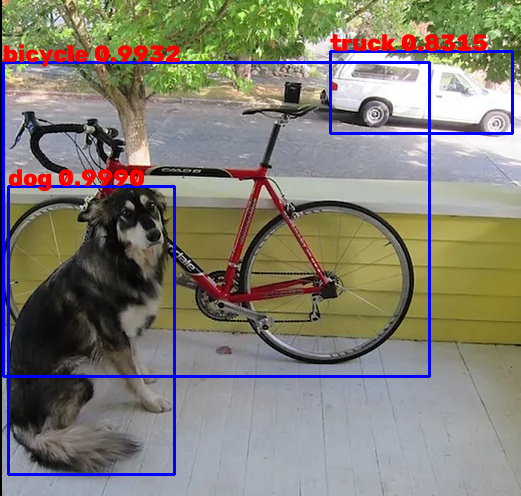

In [57]:
# 【顯示與儲存結果】
# 用 OpenCV 重新讀入原圖，將預測框/類別/分數畫上去，存成 output.jpg 並在 Colab 顯示。

img = cv2.imread(name)
img = draw_outputs(img, (boxes, scores, classes, nums), class_names)
cv2.imwrite('output.jpg', img)

cv2_imshow(img)



---



---



## 參考資料

- [YOLOv3 TensorFlow 2 實作](https://github.com/zzh8829/yolov3-tf2)
- [YOLOv3 原始論文（Joseph Redmon）](https://pjreddie.com/media/files/papers/YOLOv3.pdf)

> 相容性提醒：教材建立於較早期 TensorFlow 2/Keras 環境。若在現行 Colab 遇到 `Conv2D object has no attribute input_shape`、`numpy has no attribute product` 或權重下載失敗，通常是套件 API 或來源網址更新所致，不代表 YOLO 原理有誤。



---



---

